# EDA — ML Feature Stack
Exploratory analysis of aligned feature rasters and C_eff regression target.

**Reference grid**: 835×716, EPSG:32611, 10m  
**AOI**: montecito_aoi.shp  
**Target**: C_eff_mean (local soil resistance, Pa)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
import warnings
warnings.filterwarnings('ignore')

ALIGNED = Path('/mnt/c/Users/amehedi/Downloads/thomas/aligned')
NODATA  = -9999.0

FEATURES = {
    # terrain
    'slope':          ALIGNED / 'slope_aligned.tif',
    'drainage_area':  ALIGNED / 'drainage_area_aligned.tif',
    'curvature':      ALIGNED / 'curvature_aligned.tif',
    'aspect':         ALIGNED / 'aspect_aligned.tif',
    'elevation':      ALIGNED / 'elevation_aligned.tif',
    # fire
    'burn_severity':  ALIGNED / 'burn_severity_aligned.tif',
    'et_diff':        ALIGNED / 'et_diff_aligned.tif',
    'ndvi_diff':      ALIGNED / 'ndvi_diff_aligned.tif',
    # soil
    'soil_thickness': ALIGNED / 'soil_thickness_aligned.tif',
    'sand_total':     ALIGNED / 'sand_total_aligned.tif',
    'silt_total':     ALIGNED / 'silt_total_aligned.tif',
    'clay_total':     ALIGNED / 'clay_total_aligned.tif',
    'porosity':       ALIGNED / 'porosity_aligned.tif',
    'ksat':           ALIGNED / 'ksat_aligned.tif',
    'ph':             ALIGNED / 'ph_aligned.tif',
    'field_capacity': ALIGNED / 'field_capacity_aligned.tif',
    # precipitation
    'precip_jan9':    ALIGNED / 'precip_jan9_aligned.tif',
    'precip_jan10':   ALIGNED / 'precip_jan10_aligned.tif',
}
TARGET_PATH = ALIGNED / 'C_eff_mean_aligned.tif'

def load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
    arr[arr == NODATA] = np.nan
    return arr

print('Loading features...')
data = {name: load(path) for name, path in FEATURES.items()}
target = load(TARGET_PATH)
print(f'Grid: {target.shape}  AOI valid cells: {np.isfinite(target).sum():,}')

## 1. Descriptive Statistics

In [ ]:
rows = []
for name, arr in {'C_eff (target)': target, **data}.items():
    vals = arr[np.isfinite(arr)].ravel()
    rows.append({
        'feature':   name,
        'n_valid':   len(vals),
        'n_unique':  int(pd.Series(vals).nunique()),
        'mean':      float(vals.mean()),
        'std':       float(vals.std()),
        'min':       float(vals.min()),
        'p25':       float(np.percentile(vals, 25)),
        'median':    float(np.median(vals)),
        'p75':       float(np.percentile(vals, 75)),
        'max':       float(vals.max()),
        'skewness':  float(pd.Series(vals).skew()),
        'n_nodata':  int(np.isnan(arr).sum()),
    })

stats = pd.DataFrame(rows).set_index('feature')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)
stats

In [ ]:
# Flag potentially constant or near-constant features
print('Features with n_unique < 50 (likely near-constant within AOI):')
print(stats[stats['n_unique'] < 50][['n_unique', 'mean', 'std']])

## 2. Target Distribution (C_eff)

In [ ]:
t_vals = target[np.isfinite(target)].ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(t_vals, bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(np.median(t_vals), color='red',    lw=1.5, label=f'median={np.median(t_vals):.1f}')
axes[0].axvline(t_vals.mean(),     color='orange', lw=1.5, label=f'mean={t_vals.mean():.1f}')
axes[0].set_xlabel('C_eff (Pa)')
axes[0].set_ylabel('count')
axes[0].set_title('C_eff distribution')
axes[0].legend()

axes[1].hist(np.log1p(t_vals), bins=80, color='steelblue', edgecolor='none')
axes[1].set_xlabel('log(1 + C_eff)')
axes[1].set_title('C_eff log-transformed')

plt.tight_layout()
plt.show()
print(f'Skewness raw: {pd.Series(t_vals).skew():.2f}  |  log1p: {pd.Series(np.log1p(t_vals)).skew():.2f}')

## 3. Feature Histograms

In [ ]:
n = len(FEATURES)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.ravel()

for i, (name, arr) in enumerate(data.items()):
    vals = arr[np.isfinite(arr)].ravel()
    axes[i].hist(vals, bins=60, color='steelblue', edgecolor='none')
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions (AOI-masked, 10m)', y=1.01)
plt.tight_layout()
plt.show()

## 4. Correlation Matrix

In [ ]:
# Build flat dataframe from valid pixels (subsample for speed)
valid_mask = np.isfinite(target)
for arr in data.values():
    valid_mask &= np.isfinite(arr)

idx = np.flatnonzero(valid_mask.ravel())
rng = np.random.default_rng(42)
if len(idx) > 50_000:
    idx = rng.choice(idx, size=50_000, replace=False)

df = pd.DataFrame(
    {name: arr.ravel()[idx] for name, arr in data.items()}
)
df['C_eff'] = target.ravel()[idx]

corr = df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title('Pearson correlation matrix (50K sampled pixels)')

for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i, j]
        if abs(val) > 0.3:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if abs(val) > 0.6 else 'black')

plt.tight_layout()
plt.show()

In [ ]:
# Correlation with C_eff — sorted
ceff_corr = corr['C_eff'].drop('C_eff').sort_values(key=abs, ascending=False)
print('Correlation with C_eff (sorted by |r|):')
print(ceff_corr.to_string())

## 5. Feature vs C_eff Scatter

In [ ]:
n = len(FEATURES)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.ravel()

y = df['C_eff'].values
for i, name in enumerate(FEATURES):
    x = df[name].values
    r  = np.corrcoef(x, y)[0, 1]
    axes[i].scatter(x, y, s=1, alpha=0.2, color='steelblue', rasterized=True)
    axes[i].set_xlabel(name, fontsize=8)
    axes[i].set_ylabel('C_eff', fontsize=8)
    axes[i].set_title(f'r = {r:.2f}', fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature vs C_eff (50K sampled pixels)', y=1.01)
plt.tight_layout()
plt.show()

## 6. Spatial Maps

In [ ]:
# C_eff spatial map
fig, ax = plt.subplots(figsize=(8, 9))
t_plot = np.where(np.isfinite(target), target, np.nan)
im = ax.imshow(t_plot, cmap='RdYlGn_r', vmin=0, vmax=200)
plt.colorbar(im, ax=ax, label='C_eff (Pa)', shrink=0.7)
ax.set_title('C_eff mean — Montecito watershed (10m)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Spatial maps of top correlated features
top_features = ceff_corr.abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, name in enumerate(top_features):
    arr = data[name]
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    im = axes[i].imshow(arr, cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=axes[i], shrink=0.7)
    r = ceff_corr[name]
    axes[i].set_title(f'{name}  (r={r:.2f})', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Top 6 features correlated with C_eff')
plt.tight_layout()
plt.show()

## 7. Collinearity Check — Sand / Silt / Clay

In [ ]:
soil_cols = ['sand_total', 'silt_total', 'clay_total']
print('Sand + Silt + Clay sum stats (should be ~100%):')
soil_sum = df[soil_cols].sum(axis=1)
print(soil_sum.describe())

print('\nPairwise correlations:')
print(df[soil_cols].corr().to_string())

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
from rasterio.features import geometry_mask

ALIGNED  = Path('/mnt/c/Users/amehedi/Downloads/thomas/aligned')
ML_OUT   = Path('/mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest_regressor')
POLY_PATH = Path('/mnt/c/Users/amehedi/Downloads/train_test_poly1.gpkg')
NODATA   = -9999.0

def load(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
        profile = src.profile
        arr[arr == NODATA] = np.nan
    return arr, profile

obs,  prof = load(ALIGNED  / 'C_eff_mean_aligned.tif')
pred, _    = load(ML_OUT   / 'random_forest_regressor_prediction.tif')

# Build split masks from polygons
gdf = gpd.read_file(POLY_PATH).to_crs(prof['crs'])
shape = obs.shape
transform = prof['transform']

SPLITS = {
    'train': [1, 2, 3, 4, 5, 6],
    'val':   [],        # val is random subset of train — use train mask
    'test':  [7, 8],
}

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (split_name, ids) in zip(axes, [('train', [1,2,3,4,5,6]),
                                         ('test',  [7,8])]):
    chosen = gdf[gdf['id'].isin(ids)]
    mask = geometry_mask(
        [g for g in chosen.geometry if g and not g.is_empty],
        out_shape=shape, transform=transform, invert=True
    )
    valid = mask & np.isfinite(obs) & np.isfinite(pred)
    
    y_obs  = obs[valid].ravel()
    y_pred = pred[valid].ravel()
    
    rng = np.random.default_rng(42)
    if len(y_obs) > 20_000:
        idx = rng.choice(len(y_obs), 20_000, replace=False)
        y_obs, y_pred = y_obs[idx], y_pred[idx]
    
    r2 = np.corrcoef(y_obs, y_pred)[0,1]**2
    vmax = np.percentile(np.concatenate([y_obs, y_pred]), 98)
    
    ax.scatter(y_obs, y_pred, s=1, alpha=0.3, color='steelblue', rasterized=True)
    ax.plot([0, vmax], [0, vmax], 'r--', lw=1, label='1:1')
    ax.set_xlabel('Observed C_eff')
    ax.set_ylabel('Predicted C_eff')
    ax.set_title(f'{split_name}  (R²={r2:.3f}, n={len(y_obs):,})')
    ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
    ax.legend(fontsize=8)

plt.suptitle('Observed vs Predicted C_eff', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (split_name, ids) in zip(axes, [('train', [1,2,3,4,5,6]),
                                         ('test',  [7,8])]):
    chosen = gdf[gdf['id'].isin(ids)]
    mask = geometry_mask(
        [g for g in chosen.geometry if g and not g.is_empty],
        out_shape=shape, transform=transform, invert=True
    )
    valid = mask & np.isfinite(obs) & np.isfinite(pred)

    y_obs  = obs[valid].ravel()
    y_pred = pred[valid].ravel()

    rng = np.random.default_rng(42)
    if len(y_obs) > 20_000:
        idx = rng.choice(len(y_obs), 20_000, replace=False)
        y_obs, y_pred = y_obs[idx], y_pred[idx]

    r2   = np.corrcoef(y_obs, y_pred)[0,1]**2
    mae  = np.mean(np.abs(y_obs - y_pred))
    rmse = np.sqrt(np.mean((y_obs - y_pred)**2))
    vmax = np.percentile(np.concatenate([y_obs, y_pred]), 98)

    # density hexbin
    hb = ax.hexbin(y_obs, y_pred, gridsize=60, cmap='Blues',
                   extent=[0, vmax, 0, vmax], mincnt=1)
    plt.colorbar(hb, ax=ax, label='count', shrink=0.8)

    # 1:1 line
    ax.plot([0, vmax], [0, vmax], 'r--', lw=1.5, label='1:1')

    # best-fit line + equation
    slope, intercept, _, _, _ = stats.linregress(y_obs, y_pred)
    x_fit = np.array([0, vmax])
    ax.plot(x_fit, slope * x_fit + intercept, 'k-', lw=1.5,
            label=f'fit: y = {slope:.2f}x + {intercept:.1f}')

    ax.set_xlabel('Observed C_eff', fontsize=15)
    ax.set_ylabel('Predicted C_eff', fontsize=15)
    ax.set_title(
        f'{split_name}  |  R²={r2:.3f}  MAE={mae:.1f}  RMSE={rmse:.1f}',
        fontsize=14
    )
    ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=14)

plt.suptitle('Observed vs Predicted C_eff', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import rasterio
from pathlib import Path

ALIGNED = Path('/mnt/c/Users/amehedi/Downloads/thomas/aligned')

with rasterio.open(ALIGNED / 'C_eff_mean_aligned.tif') as src:
    arr = src.read(1).astype('float32')
    profile = src.profile.copy()
    nodata = src.nodata

arr[arr == nodata] = np.nan
log_arr = np.log1p(arr)

out = np.where(np.isfinite(log_arr), log_arr, -9999.0).astype('float32')
profile.update(nodata=-9999.0)

with rasterio.open(ALIGNED / 'C_eff_log1p_aligned.tif', 'w', **profile) as dst:
    dst.write(out, 1)

print(f'Done. min={np.nanmin(log_arr):.3f}  max={np.nanmax(log_arr):.3f}  mean={np.nanmean(log_arr):.3f}')

In [ ]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from scipy import stats

with rasterio.open("/mnt/c/Users/amehedi/Downloads/thomas/aligned/C_eff_mean_aligned.tif") as f:
    x = f.read(1).ravel()

x = x[(x > 0) & (x < 9000)]  # remove nodata

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gamma fit
a, loc, scale = stats.gamma.fit(x, floc=0)
axes[0].hist(x, bins=80, density=True, alpha=0.6)
xg = np.linspace(0, np.percentile(x, 99), 300)
axes[0].plot(xg, stats.gamma.pdf(xg, a, loc, scale), 'r-', lw=2, label=f"Gamma α={a:.2f}")
axes[0].set_title("C_eff vs Gamma fit"); axes[0].legend()

# Log-normal check
axes[1].hist(np.log(x), bins=80, density=True, alpha=0.6)
mu, sig = np.mean(np.log(x)), np.std(np.log(x))
xl = np.linspace(np.log(x).min(), np.log(x).max(), 300)
axes[1].plot(xl, stats.norm.pdf(xl, mu, sig), 'r-', lw=2, label="Normal fit")
axes[1].set_title("log(C_eff) — log-normal check"); axes[1].legend()

plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

ALIGNED = "/mnt/c/Users/amehedi/Downloads/thomas/aligned/"
TARGET  = ALIGNED + "C_eff_log1p_aligned.tif"
POLYS   = "/mnt/c/Users/amehedi/Downloads/train_test_poly1.gpkg"

SCENARIOS = {
    "S1": ["slope","aspect","elevation","et_diff","ndvi_diff","soil_thickness","sand_total","silt_total","ksat"],
    "S2": ["aspect","elevation","et_diff","ndvi_diff"],
    "S3": ["slope","aspect","elevation"],
}

FEAT_PATHS = {
    "slope":          ALIGNED + "slope_aligned.tif",
    "drainage_area":  ALIGNED + "drainage_area_aligned.tif",
    "curvature":      ALIGNED + "curvature_aligned.tif",
    "aspect":         ALIGNED + "aspect_aligned.tif",
    "elevation":      ALIGNED + "elevation_aligned.tif",
    "et_diff":        ALIGNED + "et_diff_aligned.tif",
    "ndvi_diff":      ALIGNED + "ndvi_diff_aligned.tif",
    "soil_thickness": ALIGNED + "soil_thickness_aligned.tif",
    "sand_total":     ALIGNED + "sand_total_aligned.tif",
    "silt_total":     ALIGNED + "silt_total_aligned.tif",
    "ksat":           ALIGNED + "ksat_aligned.tif",
    "ph":             ALIGNED + "ph_aligned.tif",
    "precip_jan9":    ALIGNED + "precip_jan9_aligned.tif",
}

# Load target + reference profile
with rasterio.open(TARGET) as f:
    target = f.read(1); profile = f.profile; shape = target.shape; transform = f.transform

# Build train/test masks from polygons
gdf = gpd.read_file(POLYS).to_crs("EPSG:32611")
def poly_mask(ids):
    shapes = [(g, 1) for g, i in zip(gdf.geometry, gdf["id"]) if i in ids]
    return rasterize(shapes, out_shape=shape, transform=transform, fill=0).astype(bool)

train_mask = poly_mask([1,2,3,4,5,6])
test_mask  = poly_mask([7,8])

# Run each scenario
for name, feats in SCENARIOS.items():
    arrays = []
    for f in feats:
        with rasterio.open(FEAT_PATHS[f]) as src:
            arrays.append(src.read(1))

    X = np.stack(arrays, axis=-1)  # H x W x F
    y = target

    valid = np.isfinite(X).all(axis=-1) & np.isfinite(y) & (y > 0)

    tr = valid & train_mask
    te = valid & test_mask

    X_tr, y_tr = X[tr], y[tr]
    X_te, y_te = X[te], y[te]

    rf = RandomForestRegressor(n_estimators=400, max_depth=30, min_samples_leaf=20,
                               max_features="log2", random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    r2_tr = r2_score(y_tr, rf.predict(X_tr))
    r2_te = r2_score(y_te, rf.predict(X_te))
    mae_te = mean_absolute_error(y_te, rf.predict(X_te))

    print(f"{name} ({', '.join(feats)})")
    print(f"  Train R²={r2_tr:.3f}  |  Test R²={r2_te:.3f}  MAE={mae_te:.3f}\n")

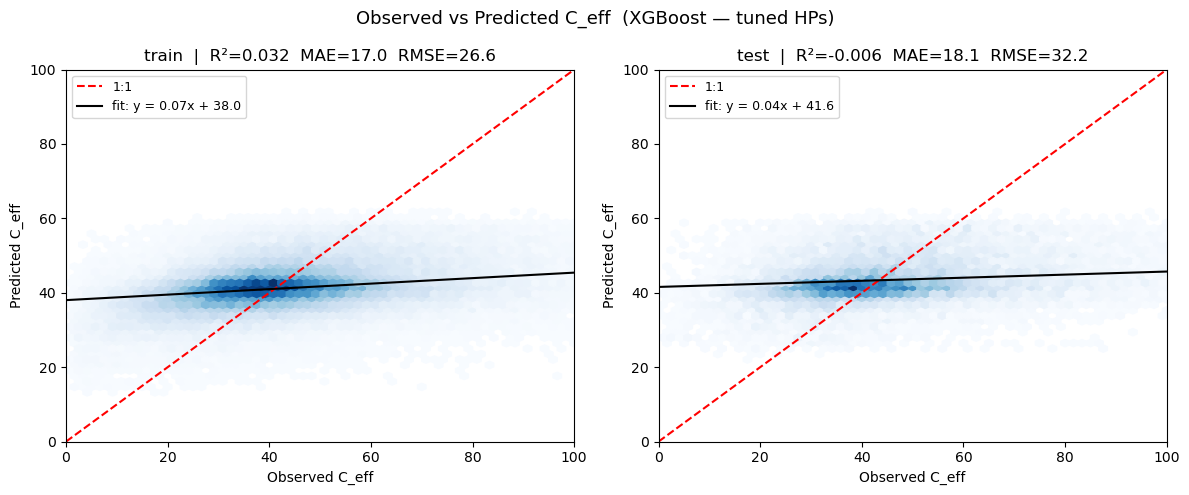

In [2]:
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.features import rasterize
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

OUT    = "/mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/xgboost_regressor/"
TARGET = "/mnt/c/Users/amehedi/Downloads/thomas/aligned/C_eff_log1p_aligned.tif"
POLYS  = "/mnt/c/Users/amehedi/Downloads/train_test_poly1.gpkg"

with rasterio.open(OUT + "xgboost_regressor_prediction.tif") as f:
    pred_log = f.read(1); shape = f.shape; transform = f.transform
with rasterio.open(TARGET) as f:
    targ_log = f.read(1)

pred = np.expm1(pred_log)
targ = np.expm1(targ_log)

gdf = gpd.read_file(POLYS).to_crs("EPSG:32611")
def poly_mask(ids):
    shapes = [(g, 1) for g, i in zip(gdf.geometry, gdf["id"]) if i in ids]
    return rasterize(shapes, out_shape=shape, transform=transform, fill=0).astype(bool)

train_mask = poly_mask([1,2,3,4,5,6])
test_mask  = poly_mask([7,8])

def get_vals(mask):
    valid = mask & np.isfinite(pred) & np.isfinite(targ) & (targ > 0)
    return targ[valid], pred[valid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, mask) in zip(axes, [("train", train_mask), ("test", test_mask)]):
    obs, hat = get_vals(mask)
    r2   = r2_score(obs, hat)
    mae  = mean_absolute_error(obs, hat)
    rmse = np.sqrt(mean_squared_error(obs, hat))
    lim  = (0, 100)
    ax.hexbin(obs, hat, gridsize=60, cmap="Blues", extent=(*lim, *lim), mincnt=1)
    ax.plot(lim, lim, 'r--', lw=1.5, label="1:1")
    m, b = np.polyfit(obs, hat, 1)
    ax.plot(np.array(lim), m*np.array(lim)+b, 'k-', lw=1.5, label=f"fit: y = {m:.2f}x + {b:.1f}")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Observed C_eff"); ax.set_ylabel("Predicted C_eff")
    ax.set_title(f"{label}  |  R²={r2:.3f}  MAE={mae:.1f}  RMSE={rmse:.1f}")
    ax.legend(fontsize=9)

fig.suptitle("Observed vs Predicted C_eff  (XGBoost — tuned HPs)", fontsize=13)
plt.tight_layout(); plt.show()
